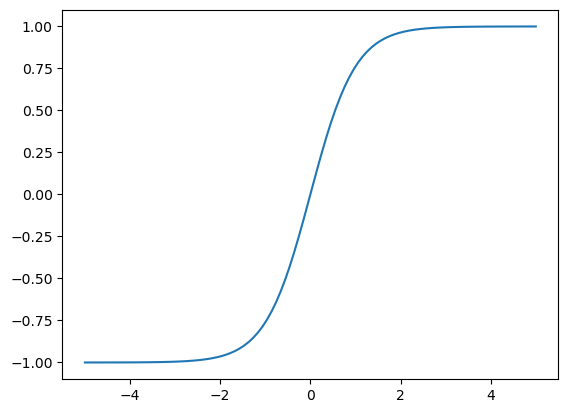

In [ ]:
# RNN => 순환 신경망
# sigmoid, relu, tanh
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)

y = np.tanh(x)

plt.plot(x, y)



In [4]:
inputs = [1, 2, 3]

# 초기 hidden 값
h = 0

# h 값이 1을 넘지 않음
for step, x in enumerate(inputs, start=1):
    h = np.tanh(x + h)
    print(f"{step}: {h}")

1: 0.7615941559557649
2: 0.9920455700292888
3: 0.9993185480009414


In [ ]:
# 다음 숫자예측

import numpy as np

x = []
y = []

for i in range(6):
    lst = np.array(range(i, i + 4)) / 10
    lst = lst.reshape(-1, 1)
    x.append(lst)
    y.append((i + 4)/ 10)

x = np.array(x)
y = np.array(y)

# RNN 의 데이터셋 구조 => (n, timestemp, feature)
x.shape, y.shape

((6, 4, 1), (6,))

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

model = tf.keras.Sequential([
    layers.Input(shape=(4, 1)),

    # 파라미터 갯수 뽑는것 이해 안됨
    # (1*10) + (10*10) + 10 = 120
    layers.SimpleRNN(units=10, activation="tanh", return_sequences=True),

     # (10*10) + (10*10) + 10 = 210
    layers.SimpleRNN(units=10, activation="relu", return_sequences=False),
    layers.Dense(units=1, activation="linear")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 4, 10)          │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 341 (1.33 KB)

 Trainable params: 341 (1.33 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [12]:
model.fit(x, y, epochs=1000, verbose=2)

Epoch 1/1000
1/1 - 2s - 2s/step - loss: 0.0798 - mae: 0.2607
Epoch 2/1000
1/1 - 0s - 33ms/step - loss: 0.0579 - mae: 0.2189
Epoch 3/1000
1/1 - 0s - 35ms/step - loss: 0.0399 - mae: 0.1775
Epoch 4/1000
1/1 - 0s - 36ms/step - loss: 0.0257 - mae: 0.1367
Epoch 5/1000
1/1 - 0s - 34ms/step - loss: 0.0153 - mae: 0.1006
Epoch 6/1000
1/1 - 0s - 37ms/step - loss: 0.0084 - mae: 0.0722
Epoch 7/1000
1/1 - 0s - 35ms/step - loss: 0.0046 - mae: 0.0559
Epoch 8/1000
1/1 - 0s - 38ms/step - loss: 0.0035 - mae: 0.0514
Epoch 9/1000
1/1 - 0s - 38ms/step - loss: 0.0042 - mae: 0.0575
Epoch 10/1000
1/1 - 0s - 34ms/step - loss: 0.0061 - mae: 0.0691
Epoch 11/1000
1/1 - 0s - 35ms/step - loss: 0.0083 - mae: 0.0801
Epoch 12/1000
1/1 - 0s - 35ms/step - loss: 0.0103 - mae: 0.0913
Epoch 13/1000
1/1 - 0s - 37ms/step - loss: 0.0116 - mae: 0.0991
Epoch 14/1000
1/1 - 0s - 35ms/step - loss: 0.0121 - mae: 0.1021
Epoch 15/1000
1/1 - 0s - 36ms/step - loss: 0.0117 - mae: 0.1009
Epoch 16/1000
1/1 - 0s - 36ms/step - loss: 0.0107 -

In [13]:
from sklearn.metrics import r2_score

y_pred = model.predict(x)
r2_score(y, y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step


0.9998186211178969

In [14]:
import numpy as np

#(n, step, feature)
sample = np.array([[[0.5], [0.6,], [0.7], [0.8]]])
sample.shape

(1, 4, 1)

In [16]:
model.input_shape

(None, 4, 1)

In [15]:
model.predict(sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step


array([[0.89690423]], dtype=float32)

In [17]:
import pandas as pd

df = pd.read_csv("http://114.207.245.181:13000/csv/supply.csv")
df

,수요량,생산능력,재고량,월,공급량
0,950,1000,200,1월,250
1,1050,1100,180,2월,230
2,980,1000,150,3월,170
3,1020,1050,130,4월,160
4,1100,1150,140,5월,190
5,1200,1250,160,6월,210
6,1400,1450,170,7월,220
7,1350,1400,160,8월,210
8,1300,1350,150,9월,200
9,1250,1300,140,10월,190


In [21]:
x = df[['수요량', '생산능력', '재고량']].values
y = df[['공급량']].values
x.shape, y.shape

((12, 3), (12, 1))

In [ ]:
# 0~1 사이의 숫자로 정규화(스케일)
from sklearn.preprocessing import MinMaxScaler

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

x_scaled = x_scaler.fit_transform(x)
y_scaled = y_scaler.fit_transform(y)

x_scaled[:3], y_scaled[:3]

(array([[0.        , 0.        , 1.        ],
        [0.22222222, 0.22222222, 0.75      ],
        [0.06666667, 0.        , 0.375     ]]),
 array([[1.        ],
        [0.77777778],
        [0.11111111]]))

In [ ]:
# 3개월 치이므로 12달 에서 9번만 fit할 수 있다 
# n = 9
# 3개월치 = 3
# 특성 = 3
# 따라서 shape=(9, 3, 3)
# NOTE: 마지막 3개월 10월 11월 12월 은 못함 왜냐하면 내년 1월달 정답 생산량이 데이터에 없음

import numpy as np
timesteps = 3

x = []
y = []

for i in range(len(df)- timesteps):
    x.append( x_scaled [i:i+timesteps])
    y.append( y_scaled [i+timesteps])

x = np.array(x)
y = np.array(y)

x.shape, y.shape

((9, 3, 3), (9, 1))

In [ ]:
# NOTE: 훈련, 확인 데이터 분할 주의사항. 
# 시계열 데이터는 순서가 중요하고 sklearn train_and_split는 랜덤하게 데이터를 분할하므로 적합하지 않다.

split = int(len(x) * 0.8)

x_train = x[:split]
x_test = x[split:]
y_train = y[:split]
y_test = y[split:]

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((7, 3, 3), (2, 3, 3), (7, 1), (2, 1))

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.models import Sequential

model = Sequential([
    Input(shape=(3,3)),
    
    # (3*10) +(10*10) + 10) => 140 * 4gate
    LSTM(units=10, activation="tanh", return_sequences=True),

    #  (10 * 50) + (50 * 50) + 50 => 3050 * 4gate
    LSTM(units=50, activation="relu", return_sequences=False),

    Dense(units=1, activation="linear")
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 3, 10)          │           560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        12,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,811 (50.04 KB)

 Trainable params: 12,811 (50.04 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [31]:
model.fit(x_train, y_train, epochs=2000, validation_data=(x_test, y_test), verbose=2)

Epoch 1/2000
1/1 - 0s - 318ms/step - loss: 9.4496e-08 - mae: 2.3887e-04 - val_loss: 0.0367 - val_mae: 0.1732
Epoch 2/2000
1/1 - 0s - 66ms/step - loss: 9.7716e-08 - mae: 2.1895e-04 - val_loss: 0.0367 - val_mae: 0.1732
Epoch 3/2000
1/1 - 0s - 64ms/step - loss: 9.6557e-08 - mae: 2.4918e-04 - val_loss: 0.0367 - val_mae: 0.1732
Epoch 4/2000
1/1 - 0s - 67ms/step - loss: 9.2119e-08 - mae: 2.4504e-04 - val_loss: 0.0367 - val_mae: 0.1732
Epoch 5/2000
1/1 - 0s - 69ms/step - loss: 9.0655e-08 - mae: 2.3130e-04 - val_loss: 0.0367 - val_mae: 0.1732
Epoch 6/2000
1/1 - 0s - 68ms/step - loss: 9.4179e-08 - mae: 2.5699e-04 - val_loss: 0.0367 - val_mae: 0.1732
Epoch 7/2000
1/1 - 0s - 69ms/step - loss: 8.9756e-08 - mae: 2.0792e-04 - val_loss: 0.0367 - val_mae: 0.1732
Epoch 8/2000
1/1 - 0s - 68ms/step - loss: 8.6218e-08 - mae: 2.1992e-04 - val_loss: 0.0367 - val_mae: 0.1732
Epoch 9/2000
1/1 - 0s - 68ms/step - loss: 8.9801e-08 - mae: 2.2654e-04 - val_loss: 0.0367 - val_mae: 0.1732
Epoch 10/2000
1/1 - 0s - 67

In [32]:
from sklearn.metrics import r2_score

y_pred_scaled = model.predict(x_test)
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_real = y_scaler.inverse_transform(y_test)

r2_score(y_real, y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


0.24545306414918744

In [ ]:
p = np.array([x[-1]])
p.shape

(1, 3, 3)

In [40]:
p_y = model.predict(p)
p_y_real = y_scaler.inverse_transform(p_y)
p_y_real

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


array([[211.93741]], dtype=float32)

In [52]:
last_3_month = x[-3:]
sample = last_3_month.reshape(-1, 3, 3)
pred_sample = model.predict(sample)
y_scaler.inverse_transform(pred_sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


array([[190.     ],
       [203.20845],
       [211.93741]], dtype=float32)